In [130]:
import pandas as pd

# Cargar dataset
df = pd.read_csv('../data/historicos_2022.csv', decimal=',')

# Vista rápida
df.head()


,ID_PREDIO,NUMERO_PREDIAL_NACIONAL,COMUNA,BARRIO,MANZANA,TERRENO,PREDIO,VIGENCIA,DESCRIP_CONDICION_PROPIEDAD,ID_TERRENO,AREA_CONSTRUCCION,AREA_TERRENO,VALOR_TERR,VALOR_CONST,DESTINO_ECONOMICO,AVALUO,AREA_ANEXO,VALOR_ANEXO
0,885102,760010100177400690001903990475,17,74,69,1,475,1/1/2022,PH,1.774007e+11,12,4.0,3127957.56,7596468.36,411,10724425.92,0.0,0.00
1,915228,760010100177500980020901050102,17,75,98,20,102,1/1/2022,PH,1.775010e+11,55,36.0,28285291.44,58093902.18,2,86379193.62,0.0,0.00
2,2237,760010100021700870001000000001,2,17,87,1,1,1/1/2022,NPH,2.170087e+10,0,247.0,30493338.37,0.00,0,30493338.37,0.0,0.00
3,2239,760010100021700840001000000001,2,17,84,1,1,1/1/2022,NPH,2.170084e+10,0,147.0,18147857.25,0.00,0,18147857.25,0.0,0.00
4,9969,760010000560000030002500000003,56,0,3,2,3,1/1/2022,MEJORAS POR EDIFICACIONES EN TERRENO AJENO DE ...,5.600030e+09,250,0.0,0.00,48940140.93,1003,52008719.54,86.0,3068578.61


In [131]:
cols_a_dropear = [
    'ID_PREDIO', 'NUMERO_PREDIAL_NACIONAL', 'TERRENO', 'PREDIO',
    'ID_TERRENO', 'MANZANA', 'VIGENCIA', 'BARRIO', 'VALOR_TERR',
    'VALOR_ANEXO', 'VALOR_CONST', 'DESTINO_ECONOMICO'
]

df_clean = df.drop(columns=cols_a_dropear)

df_clean.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
COMUNA,750068.0,NaN,NaN,NaN,15.968968,14.08601,1.0,6.0,15.0,19.0,65.0
DESCRIP_CONDICION_PROPIEDAD,750068,7,PH,334416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AREA_CONSTRUCCION,750068.0,NaN,NaN,NaN,105.738988,529.678221,0.0,22.0,63.0,123.0,261113.0
AREA_TERRENO,750068.0,NaN,NaN,NaN,707.369826,46058.154699,0.0,12.0,52.0,105.0,26264686.0
AVALUO,750068.0,NaN,NaN,NaN,114016403.092402,1083046342.83265,251.93,16034399.475,55382268.21,109164552.05,629728560513.719971
AREA_ANEXO,750068.0,NaN,NaN,NaN,8.231801,353.721143,0.0,0.0,0.0,0.0,196208.0


In [132]:
df_clean['TIENE_ANEXO'] = (df_clean['AREA_ANEXO'] > 0).astype(int)

df_clean = df_clean[(df_clean['AVALUO'] >= 3e7) & (df_clean['AVALUO'] <= 1e9)]
df_clean.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
COMUNA,474273.0,NaN,NaN,NaN,14.249898,12.271112,1.0,6.0,13.0,17.0,65.0
DESCRIP_CONDICION_PROPIEDAD,474273,7,NPH,243832,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AREA_CONSTRUCCION,474273.0,NaN,NaN,NaN,123.735045,94.249909,0.0,59.0,94.0,160.0,2570.0
AREA_TERRENO,474273.0,NaN,NaN,NaN,479.247502,19114.012802,0.0,40.0,73.0,132.0,7518431.0
AVALUO,474273.0,NaN,NaN,NaN,111781611.393922,83106964.7892,30000788.0,55664536.41,84619347.65,138657871.28,499973836.33
AREA_ANEXO,474273.0,NaN,NaN,NaN,5.911457,34.353412,0.0,0.0,0.0,0.0,8152.0
TIENE_ANEXO,474273.0,NaN,NaN,NaN,0.155408,0.362294,0.0,0.0,0.0,0.0,1.0


In [133]:
for col in ['DESCRIP_CONDICION_PROPIEDAD', 'COMUNA', 'TIENE_ANEXO']:
    df_clean[col] = df_clean[col].astype('category')
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 474273 entries, 1 to 750067
Data columns (total 7 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   COMUNA                       474273 non-null  category
 1   DESCRIP_CONDICION_PROPIEDAD  474273 non-null  category
 2   AREA_CONSTRUCCION            474273 non-null  int64   
 3   AREA_TERRENO                 474273 non-null  float64 
 4   AVALUO                       474273 non-null  float64 
 5   AREA_ANEXO                   474273 non-null  float64 
 6   TIENE_ANEXO                  474273 non-null  category
dtypes: category(3), float64(3), int64(1)
memory usage: 19.5 MB


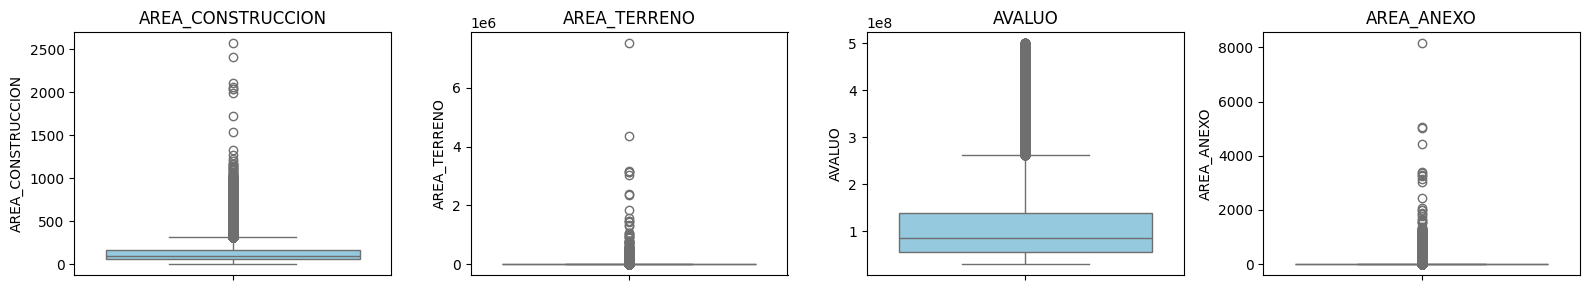

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns

n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(16, 3*n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df_clean[col], color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

In [135]:
import numpy as np

# Nos aseguramos de tener TIENE_ANEXO (si ya existe, no cambia)
if 'TIENE_ANEXO' not in df_clean.columns:
    df_clean['TIENE_ANEXO'] = (df_clean['AREA_ANEXO'] > 0).astype(int)

# Máscara para filas con anexo
mask_anexo = df_clean['TIENE_ANEXO'] == 1

# Columnas numéricas excepto AVALUO
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.drop('AVALUO')

df_outliers = df_clean.copy()

# Guardamos conteos de reemplazos por columna
replaced_counts = {}

for col in numeric_cols:
    # Selección de datos para calcular Q1/Q3 según la columna
    if col == 'AREA_ANEXO':
        # calcular IQR solo con filas que tienen anexo
        series_for_iqr = df_outliers.loc[mask_anexo, col].dropna()
    else:
        # para el resto, calcular con todo el df (dropna)
        series_for_iqr = df_outliers[col].dropna()

    # Si hay pocos datos válidos, saltar la columna
    if series_for_iqr.shape[0] < 4:
        replaced_counts[col] = 0
        print(f"Saltando {col}: muestra muy pequeña para IQR ({series_for_iqr.shape[0]} valores).")
        continue

    Q1 = series_for_iqr.quantile(0.25)
    Q3 = series_for_iqr.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    if col == 'AREA_ANEXO':
        # Detectar outliers SOLO en filas con anexo
        outliers_mask = mask_anexo & (
            (df_outliers[col] < lower_bound) | (df_outliers[col] > upper_bound)
        )
    elif col == 'VALOR_ANEXO':
        # Para VALOR_ANEXO: no marcar como outlier si el valor es exactamente 0
        # (pero sí marcar otros outliers)
        outliers_mask = (
            ((df_outliers[col] < lower_bound) | (df_outliers[col] > upper_bound))
            & (df_outliers[col] != 0)  # excluye ceros de ser considerados outlier
            & df_outliers[col].notna()
        )
    else:
        # Comportamiento "normal" para las demás columnas
        outliers_mask = (
            ((df_outliers[col] < lower_bound) | (df_outliers[col] > upper_bound))
            & df_outliers[col].notna()
        )

    # Reemplazar por NaN solo las posiciones detectadas
    replaced_before = df_outliers.loc[outliers_mask, col].shape[0]
    df_outliers.loc[outliers_mask, col] = np.nan
    replaced_counts[col] = replaced_before

# Resumen
print("\nResumen de valores reemplazados por columna (outliers -> NaN):")
for c, cnt in replaced_counts.items():
    print(f"  {c}: {cnt}")

# Mostrar primeras filas del resultado
display(df_outliers.head())



Resumen de valores reemplazados por columna (outliers -> NaN):
  AREA_CONSTRUCCION: 23649
  AREA_TERRENO: 21429
  AREA_ANEXO: 6417


,COMUNA,DESCRIP_CONDICION_PROPIEDAD,AREA_CONSTRUCCION,AREA_TERRENO,AVALUO,AREA_ANEXO,TIENE_ANEXO
1,17,PH,55.0,36.0,86379193.62,0.0,0
2,2,NPH,0.0,247.0,30493338.37,0.0,0
4,56,MEJORAS POR EDIFICACIONES EN TERRENO AJENO DE ...,250.0,0.0,52008719.54,86.0,1
7,59,NPH,0.0,NaN,80485068.82,0.0,0
8,54,NPH,151.0,NaN,73814383.08,91.0,1


In [136]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df_imputed = imputer.fit_transform(df_outliers.select_dtypes(include=['float64', 'int64']))

df_outliers[df_outliers.select_dtypes(include=['float64', 'int64']).columns] = df_imputed

display(df_outliers.head())

,COMUNA,DESCRIP_CONDICION_PROPIEDAD,AREA_CONSTRUCCION,AREA_TERRENO,AVALUO,AREA_ANEXO,TIENE_ANEXO
1,17,PH,55.0,36.0,86379193.62,0.0,0
2,2,NPH,0.0,247.0,30493338.37,0.0,0
4,56,MEJORAS POR EDIFICACIONES EN TERRENO AJENO DE ...,250.0,0.0,52008719.54,86.0,1
7,59,NPH,0.0,69.0,80485068.82,0.0,0
8,54,NPH,151.0,69.0,73814383.08,91.0,1


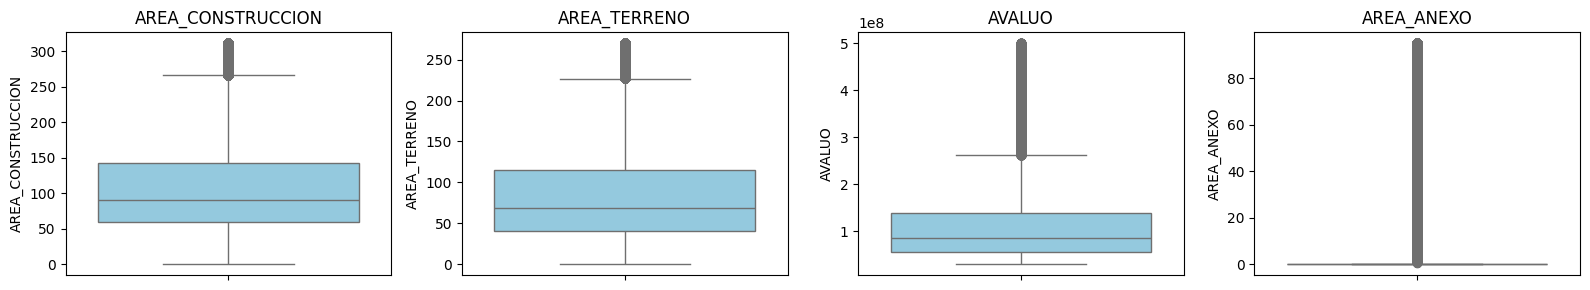

In [137]:
numeric_cols = df_outliers.select_dtypes(include=['float64', 'int64']).columns

n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(16, 3*n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df_outliers[col], color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

In [138]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Select the numerical columns to scale (excluding the target variable 'medv')
numerical_cols = df_outliers.select_dtypes(include=['float64', 'int64']).columns.drop('AVALUO')

# Apply the scaler to the selected columns
df_outliers[numerical_cols] = scaler.fit_transform(df_outliers[numerical_cols])

display(df_outliers.head())

joblib.dump(scaler, '../scripts/models/precios_casas_cali/standard_scaler.pkl')

print("StandardScaler saved successfully.")


,COMUNA,DESCRIP_CONDICION_PROPIEDAD,AREA_CONSTRUCCION,AREA_TERRENO,AVALUO,AREA_ANEXO,TIENE_ANEXO
1,17,PH,-0.809529,-0.843920,86379193.62,-0.298867,0
2,2,NPH,-1.646479,3.010653,30493338.37,-0.298867,0
4,56,MEJORAS POR EDIFICACIONES EN TERRENO AJENO DE ...,2.157839,-1.501572,52008719.54,6.848366,1
7,59,NPH,-1.646479,-0.241072,80485068.82,-0.298867,0
8,54,NPH,0.651329,-0.241072,73814383.08,7.263903,1


StandardScaler saved successfully.


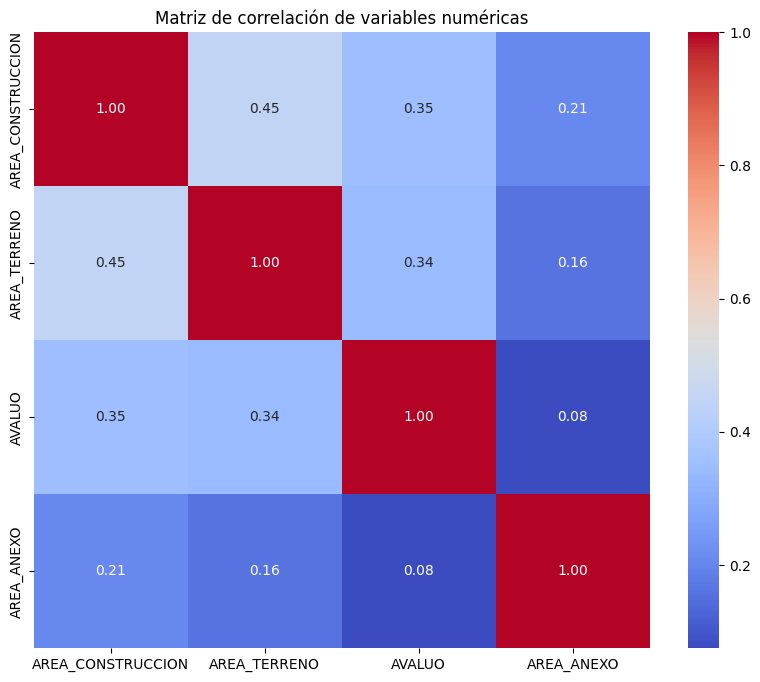

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
corr = df_outliers.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Matriz de correlación de variables numéricas")
plt.show()

In [140]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import joblib

# Columnas categóricas a codificar
cat_columns = ['COMUNA', 'DESCRIP_CONDICION_PROPIEDAD']

# Extraer solo las columnas categóricas
cat_df = df_outliers[cat_columns]

# Inicializar el OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit y transform
cat_encoded = encoder.fit_transform(cat_df)

# Crear DataFrame con los nombres codificados
encoded_feature_names = encoder.get_feature_names_out(cat_columns)
cat_encoded_df = pd.DataFrame(cat_encoded, columns=encoded_feature_names, index=df_outliers.index)

# Eliminar las columnas originales categóricas y concatenar las codificadas
df_encoded = df_outliers.drop(columns=cat_columns)
df_encoded = pd.concat([df_encoded, cat_encoded_df], axis=1)

# Mostrar resultados
display(df_encoded.head())
df_encoded.info()

# Guardar el encoder para uso posterior (por ejemplo, al predecir)
joblib.dump(encoder, '../scripts/models/precios_casas_cali/onehotencoder.pkl')


,AREA_CONSTRUCCION,AREA_TERRENO,AVALUO,AREA_ANEXO,TIENE_ANEXO,COMUNA_1,COMUNA_2,COMUNA_3,COMUNA_4,COMUNA_5,...,COMUNA_63,COMUNA_64,COMUNA_65,DESCRIP_CONDICION_PROPIEDAD_BIENES DE USO PUBLICO DIFERENTES A LAS VIAS,DESCRIP_CONDICION_PROPIEDAD_CONDOMINIO,DESCRIP_CONDICION_PROPIEDAD_MEJORAS POR EDIFICACIONES EN TERRENO AJENO DE PROPIEDADES REGLAMENTADAS EN PH,DESCRIP_CONDICION_PROPIEDAD_NPH,DESCRIP_CONDICION_PROPIEDAD_PARQUES CEMENTERIOS,DESCRIP_CONDICION_PROPIEDAD_PH,DESCRIP_CONDICION_PROPIEDAD_VIAS
1,-0.809529,-0.843920,86379193.62,-0.298867,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-1.646479,3.010653,30493338.37,-0.298867,0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2.157839,-1.501572,52008719.54,6.848366,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7,-1.646479,-0.241072,80485068.82,-0.298867,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
8,0.651329,-0.241072,73814383.08,7.263903,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
Index: 474273 entries, 1 to 750067
Data columns (total 49 columns):
 #   Column                                                                                                     Non-Null Count   Dtype   
---  ------                                                                                                     --------------   -----   
 0   AREA_CONSTRUCCION                                                                                          474273 non-null  float64 
 1   AREA_TERRENO                                                                                               474273 non-null  float64 
 2   AVALUO                                                                                                     474273 non-null  float64 
 3   AREA_ANEXO                                                                                                 474273 non-null  float64 
 4   TIENE_ANEXO                                                  

['../scripts/models/precios_casas_cali/onehotencoder.pkl']

In [161]:
df_sample = df_encoded.sample(frac=0.15, random_state=42)

print("Tamaño original:", df_encoded.shape)
print("Tamaño del muestreo (15%):", df_sample.shape)

Tamaño original: (474273, 49)
Tamaño del muestreo (15%): (71141, 49)


In [162]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_sample.drop('AVALUO', axis=1)
y = df_sample['AVALUO']

# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (49798, 48)
X_test shape: (21343, 48)
y_train shape: (49798,)
y_test shape: (21343,)


In [163]:
from sklearn.impute import KNNImputer

# Impute missing values in X_train and X_test using a separate imputer
imputer_X = KNNImputer(n_neighbors=5)
X_train_imputed = imputer_X.fit_transform(X_train)
X_test_imputed = imputer_X.transform(X_test)

# Impute missing values in y_train using another imputer
imputer_y = KNNImputer(n_neighbors=5)
y_train_imputed = imputer_y.fit_transform(y_train.values.reshape(-1, 1))

In [164]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error

# Define the MLP Regressor model
mlp_model = MLPRegressor(random_state=42, max_iter=1000)
# Initialize a dictionary to store the best models

# Define the parameter grid for MLP
param_grid_mlp = {
    'hidden_layer_sizes': [
        (50, 50),
        (100, 50),
    ],
    'activation': ['tanh'],
    'solver': ['sgd'],
    'alpha': [0.001],
    'learning_rate': ['constant'],
}

# Create the GridSearchCV object
grid_search_mlp = GridSearchCV(mlp_model, param_grid_mlp, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)

# Fit the grid search to the data
# Use the imputed data for training
grid_search_mlp.fit(X_train_imputed, y_train_imputed.ravel()) # Use ravel() to convert y_train_imputed to 1D array

# Print the best parameters and best score
print("Best parameters for MLP:", grid_search_mlp.best_params_)
print("Best cross-validation MAPE for MLP:", -grid_search_mlp.best_score_)

# Store the best model
best_mlp_grid = grid_search_mlp.best_estimator_

# Make predictions on the test set with the best model
# Use the imputed test data for prediction
y_pred_mlp_grid = best_mlp_grid.predict(X_test_imputed)

# Calculate the MAPE for the best model on the test set
mape_mlp_grid = mean_absolute_percentage_error(y_test, y_pred_mlp_grid)

print(f"Test set MAPE for best MLP model: {mape_mlp_grid:.2f}")

Best parameters for MLP: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant', 'solver': 'sgd'}
Best cross-validation MAPE for MLP: 0.6718628422645689
Test set MAPE for best MLP model: 0.73


In [189]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_percentage_error

# Define the KNN Regressor model
knn_model = KNeighborsRegressor()

param_grid_knn_expanded = {
    'n_neighbors': [5,6,7,8],
    'weights': ['distance'],
    'metric': ['manhattan'],
    'p': [1]
}

# Create the GridSearchCV object
grid_search_knn_expanded = GridSearchCV(knn_model, param_grid_knn_expanded, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)

# Fit the grid search to the data
grid_search_knn_expanded.fit(X_train_imputed, y_train_imputed.ravel())

# Print the best parameters and best score
print("Best parameters for KNN (expanded search):", grid_search_knn_expanded.best_params_)
print("Best cross-validation MAPE for KNN (expanded search):", -grid_search_knn_expanded.best_score_)

# Store the best model
best_knn_grid_expanded = grid_search_knn_expanded.best_estimator_

# Make predictions on the test set with the best model
y_pred_knn_grid_expanded = best_knn_grid_expanded.predict(X_test_imputed)

# Calculate the MAPE for the best model on the test set
mape_knn_grid_expanded = mean_absolute_percentage_error(y_test, y_pred_knn_grid_expanded)

print(f"Test set MAPE for best KNN model (expanded search): {mape_knn_grid_expanded:.2f}")


Best parameters for KNN (expanded search): {'metric': 'manhattan', 'n_neighbors': 6, 'p': 1, 'weights': 'distance'}
Best cross-validation MAPE for KNN (expanded search): 0.18696596494355347
Test set MAPE for best KNN model (expanded search): 0.19


In [194]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error

# Define the Decision Tree Regressor model
tree_model = DecisionTreeRegressor(random_state=42)

# Define an expanded parameter grid for Decision Tree to get over 200 combinations
param_grid_tree_expanded = {
    'max_depth': [None, 1],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [1, 2, 3, 4, 5],
    'criterion': ['squared_error']
}


# Create the GridSearchCV object
grid_search_tree_expanded = GridSearchCV(tree_model, param_grid_tree_expanded, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)

# Fit the grid search to the data
# Use the imputed data for training
grid_search_tree_expanded.fit(X_train_imputed, y_train_imputed.ravel())

# Print the best parameters and best score
print("Best parameters for Decision Tree (expanded search):", grid_search_tree_expanded.best_params_)
print("Best cross-validation MAPE for Decision Tree (expanded search):", -grid_search_tree_expanded.best_score_)

# Store the best model (Optional, as requested by the user to be removed)
best_tree_grid_expanded = grid_search_tree_expanded.best_estimator_

# Make predictions on the test set with the best model
# Use the imputed test data for prediction
y_pred_tree_grid_expanded = best_tree_grid_expanded.predict(X_test_imputed)

# Calculate the MAPE for the best model on the test set
mape_tree_grid_expanded = mean_absolute_percentage_error(y_test, y_pred_tree_grid_expanded)

print(f"Test set MAPE for best Decision Tree model (expanded search): {mape_tree_grid_expanded:.2f}")

Best parameters for Decision Tree (expanded search): {'criterion': 'squared_error', 'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best cross-validation MAPE for Decision Tree (expanded search): 0.17601645213476755
Test set MAPE for best Decision Tree model (expanded search): 0.18


In [196]:
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

# Define the Bayesian Ridge Regressor model
bayesian_ridge_model = BayesianRidge()

# Define an expanded parameter grid for Bayesian Ridge
param_grid_bayesian_ridge_expanded = {
    'alpha_1': np.logspace(-8, -5, 4),
    'alpha_2': np.logspace(-8, -5, 4),
    'lambda_1': np.logspace(-8, -5, 4),
    'lambda_2': np.logspace(-8, -5, 4),
}

# Create the GridSearchCV object
grid_search_bayesian_ridge_expanded = GridSearchCV(bayesian_ridge_model, param_grid_bayesian_ridge_expanded, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)

# Fit the grid search to the data
# Use the imputed data for training
grid_search_bayesian_ridge_expanded.fit(X_train_imputed, y_train_imputed.ravel())

# Print the best parameters and best score
print("Best parameters for Bayesian Ridge (expanded search):", grid_search_bayesian_ridge_expanded.best_params_)
print("Best cross-validation MAPE for Bayesian Ridge (expanded search):", -grid_search_bayesian_ridge_expanded.best_score_)

# Store the best model
best_bayesian_ridge_grid_expanded = grid_search_bayesian_ridge_expanded.best_estimator_

# Make predictions on the test set with the best model
# Use the imputed test data for prediction
y_pred_bayesian_ridge_grid_expanded = best_bayesian_ridge_grid_expanded.predict(X_test_imputed)

# Calculate the MAPE for the best model on the test set
mape_bayesian_ridge_grid_expanded = mean_absolute_percentage_error(y_test, y_pred_bayesian_ridge_grid_expanded)

print(f"Test set MAPE for best Bayesian Ridge model (expanded search): {mape_bayesian_ridge_grid_expanded:.2f}")

Best parameters for Bayesian Ridge (expanded search): {'alpha_1': np.float64(1e-08), 'alpha_2': np.float64(1e-08), 'lambda_1': np.float64(1e-07), 'lambda_2': np.float64(1e-06)}
Best cross-validation MAPE for Bayesian Ridge (expanded search): 0.3596319361142052
Test set MAPE for best Bayesian Ridge model (expanded search): 0.36


In [201]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error

# Definir el modelo Random Forest
rf_model = RandomForestRegressor(random_state=42)

# Definir una grilla de hiperparámetros para búsqueda
param_grid_rf = {
  'n_estimators': [350],
  'max_depth': [None],
  'min_samples_split': [2, 3],
  'min_samples_leaf': [1,2],
  'bootstrap': [True]
}

# Crear el objeto GridSearchCV
grid_search_rf = GridSearchCV(
  rf_model,
  param_grid_rf,
  cv=4,
  scoring='neg_mean_absolute_percentage_error',
  n_jobs=-1
)

# Entrenar el modelo usando los datos imputados
grid_search_rf.fit(X_train_imputed, y_train_imputed.ravel())

# Mostrar los mejores hiperparámetros y el mejor score
print("Best parameters for Random Forest:", grid_search_rf.best_params_)
print("Best cross-validation MAPE for Random Forest:", -grid_search_rf.best_score_)

# Guardar el mejor modelo
best_rf_grid = grid_search_rf.best_estimator_

# Predecir en el conjunto de prueba
y_pred_rf_grid = best_rf_grid.predict(X_test_imputed)

# Calcular el MAPE en el conjunto de prueba
mape_rf_grid = mean_absolute_percentage_error(y_test, y_pred_rf_grid)

print(f"Test set MAPE for best Random Forest model: {mape_rf_grid:.2f}")

Best parameters for Random Forest: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 350}
Best cross-validation MAPE for Random Forest: 0.15627198647559873
Test set MAPE for best Random Forest model: 0.16


In [203]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import StackingRegressor, BaggingRegressor


# Definir la grilla de hiperparámetros para el meta-modelo (BaggingRegressor)
param_grid_stacking = {
  'final_estimator__n_estimators': [10],
  'final_estimator__bootstrap': [False],
  'final_estimator__bootstrap_features': [True]
}

# Definir los estimadores base para el stacking
estimators = [
    ('knn', grid_search_knn_expanded.best_estimator_),
    ('tree', grid_search_tree_expanded.best_estimator_),
    ('rf', grid_search_rf.best_estimator_)
]

# Crear el StackingRegressor con los estimadores base y el meta-modelo
stacking_reg_grid = StackingRegressor(
  estimators=estimators,
  final_estimator=BaggingRegressor(random_state=42),
  n_jobs=-1
)

# Configurar el GridSearchCV
grid_search_stacking = GridSearchCV(
  stacking_reg_grid,
  param_grid_stacking,
  cv=5,
  scoring='neg_mean_absolute_percentage_error',
  n_jobs=-1
)

# Entrenar el GridSearchCV
grid_search_stacking.fit(X_train_imputed, y_train_imputed.ravel())

# Mostrar los mejores hiperparámetros y el mejor score
print("Best parameters for Stacking:", grid_search_stacking.best_params_)
print("Best cross-validation MAPE for Stacking:", -grid_search_stacking.best_score_)

# Guardar el mejor modelo
best_stacking_grid = grid_search_stacking.best_estimator_

# Predecir en el conjunto de prueba
y_pred_stacking_grid = best_stacking_grid.predict(X_test_imputed)

# Calcular el MAPE en el conjunto de prueba
mape_stacking_grid = mean_absolute_percentage_error(y_test, y_pred_stacking_grid)

print(f"Test set MAPE for best Stacking model: {mape_stacking_grid:.2f}")

Best parameters for Stacking: {'final_estimator__bootstrap': False, 'final_estimator__bootstrap_features': True, 'final_estimator__n_estimators': 10}
Best cross-validation MAPE for Stacking: 0.1925488201669993
Test set MAPE for best Stacking model: 0.19


In [204]:
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error

# Define the Bagging Regressor model
bagging_model = BaggingRegressor(random_state=42)

# Define an expanded parameter grid for Bagging Regressor
param_grid_bagging_expanded = {
    'n_estimators': [15],  # Number of base estimators
    'max_samples': [0.975, 1.0],      # The number of samples to draw from X
    'max_features': [0.975, 1.0],     # The number of features to draw from X
    'bootstrap': [True],               # Whether samples are drawn with replacement
    'bootstrap_features': [False]       # Whether features are drawn with replacement
}



# Create the GridSearchCV object
grid_search_bagging_expanded = GridSearchCV(bagging_model, param_grid_bagging_expanded, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)

# Fit the grid search to the data
# Use the imputed data for training
grid_search_bagging_expanded.fit(X_train_imputed, y_train_imputed.ravel())

# Print the best parameters and best score
print("Best parameters for Bagging Regressor (expanded search):", grid_search_bagging_expanded.best_params_)
print("Best cross-validation MAPE for Bagging Regressor (expanded search):", -grid_search_bagging_expanded.best_score_)

# Store the best model
best_bagging_grid_expanded = grid_search_bagging_expanded.best_estimator_

# Make predictions on the test set with the best model
# Use the imputed test data for prediction
y_pred_bagging_grid_expanded = best_bagging_grid_expanded.predict(X_test_imputed)

# Calculate the MAPE for the best model on the test set
mape_bagging_grid_expanded = mean_absolute_percentage_error(y_test, y_pred_bagging_grid_expanded)

print(f"Test set MAPE for best Bagging Regressor model (expanded search): {mape_bagging_grid_expanded:.2f}")


Best parameters for Bagging Regressor (expanded search): {'bootstrap': True, 'bootstrap_features': False, 'max_features': 1.0, 'max_samples': 0.975, 'n_estimators': 15}
Best cross-validation MAPE for Bagging Regressor (expanded search): 0.15895640960317967
Test set MAPE for best Bagging Regressor model (expanded search): 0.16


In [206]:
import joblib

# Save the best Bagging Regressor model
joblib.dump(best_bagging_grid_expanded, '../scripts/models/precios_casas_cali/br_model.pkl')

print("Best Bagging Regressor model saved successfully.")

Best Bagging Regressor model saved successfully.


In [ ]:
df_sample.head()